# 09 — Intra-Cluster Similarity

Measures how **cohesive** each cluster is across every unsupervised method
(tfidf_kmeans, tfidf_hdbscan, minilm_kmeans, minilm_hdbscan,
roberta_kmeans, roberta_hdbscan, bertopic).

For each method the notebook:
1. Loads or re-derives cluster assignments using the same parameters as
   notebooks 02–03 (UMAP → KMeans/HDBSCAN, or BERTopic).
2. Computes per-cluster **intra-cluster cohesion**: mean cosine similarity
   of every member article to its cluster centroid.
3. Computes **inter-cluster similarity**: cosine similarity between cluster
   centroids (how separated the clusters are from each other).
4. Saves a per-method detail table, a cluster-centroid heatmap per method,
   and a cross-method bar chart to `results/`.

Similarity is always computed in the **original embedding space** (pre-UMAP)
so that cosine distance is meaningful. UMAP is used only to derive cluster
assignments (matching notebook 02's pipeline exactly), not for measuring
distances.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hdbscan
import umap
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

from utils import config
from utils.data import stratified_sample
from utils.embeddings import load_cached

In [2]:
train_clean = pd.read_parquet(config.PROCESSED_DIR / "train_clean.parquet")
train_sample = stratified_sample(train_clean, config.SAMPLE_SIZE, seed=config.SEED)
suffix = f"n{config.SAMPLE_SIZE}" if config.SAMPLE_SIZE else "full"

true_labels = train_sample["label"].to_numpy()
summaries = train_sample["summary"].tolist()

METHODS = ["tfidf", "minilm", "roberta"]
embeddings_by_method = {}
for method in METHODS:
    arr = load_cached(f"{method}_train_{suffix}_summary")
    assert arr is not None, (
        f"Missing cached embeddings for '{method}' — run 01_embeddings.ipynb first"
    )
    embeddings_by_method[method] = arr

print(f"Rows: {len(train_sample)} | Embedding methods: {list(embeddings_by_method)}")
for m, e in embeddings_by_method.items():
    print(f"  {m}: shape {e.shape}")

Rows: 3824 | Embedding methods: ['tfidf', 'minilm', 'roberta']
  tfidf: shape (3824, 5000)
  minilm: shape (3824, 384)
  roberta: shape (3824, 768)


In [3]:
def cluster_similarity_stats(embeddings: np.ndarray, cluster_labels: np.ndarray,
                              noise_label: int = -1):
    """
    Given raw (pre-UMAP) embeddings and integer cluster labels, compute:
    - Per-cluster: size, mean/min/max cosine similarity of members to centroid
    - Centroid-to-centroid cosine similarity matrix (inter-cluster)
    - Mean off-diagonal inter-cluster similarity

    Noise rows (label == noise_label) are excluded from all calculations.
    Returns (per_cluster_df, inter_sim_matrix, cluster_ids, mean_inter_sim).
    """
    unique_clusters = sorted(c for c in np.unique(cluster_labels) if c != noise_label)
    if not unique_clusters:
        return pd.DataFrame(), np.array([[]]), [], np.nan

    rows = []
    centroids = []
    for cid in unique_clusters:
        mask = cluster_labels == cid
        members = embeddings[mask].astype(np.float32)
        centroid = members.mean(axis=0, keepdims=True)
        centroids.append(centroid[0])
        sims = cosine_similarity(members, centroid).ravel()
        rows.append({
            "cluster": cid,
            "size": int(mask.sum()),
            "mean_intra_sim": float(sims.mean()),
            "min_intra_sim": float(sims.min()),
            "max_intra_sim": float(sims.max()),
        })

    per_cluster_df = pd.DataFrame(rows)

    cent_matrix = np.stack(centroids).astype(np.float32)
    inter_mat = cosine_similarity(cent_matrix)

    n = len(unique_clusters)
    if n > 1:
        off_diag = inter_mat[~np.eye(n, dtype=bool)]
        mean_inter = float(off_diag.mean())
    else:
        mean_inter = np.nan

    return per_cluster_df, inter_mat, unique_clusters, mean_inter

print("cluster_similarity_stats() defined.")

cluster_similarity_stats() defined.


## KMeans and HDBSCAN (tfidf / minilm / roberta)

Reproduces notebook 02's pipeline: UMAP(n_components=50) reduction, then
KMeans(k=16) and HDBSCAN(min_cluster_size=50) on the reduced space. Cosine
similarity is then computed on the **original** pre-UMAP embeddings.

In [4]:
all_stats = {}       # method_name -> (per_cluster_df, inter_mat, cluster_ids)
method_summary = []  # one row per method for cross-method table

for method, emb in embeddings_by_method.items():
    print(f"\n--- {method} ---")

    # UMAP reduction — same params as notebook 02
    reducer = umap.UMAP(n_components=50, metric="cosine", random_state=config.SEED)
    emb_reduced = reducer.fit_transform(emb)

    # ── KMeans ──────────────────────────────────────────────────────────────
    km = KMeans(n_clusters=config.NUM_CLASSES, random_state=config.SEED, n_init=10)
    km_labels = km.fit_predict(emb_reduced)

    km_df, km_inter, km_cids, km_mean_inter = cluster_similarity_stats(emb, km_labels)
    km_mean_intra = float(km_df["mean_intra_sim"].mean())
    all_stats[f"{method}_kmeans"] = (km_df, km_inter, km_cids)
    method_summary.append({
        "method": f"{method}_kmeans",
        "n_clusters": len(km_cids),
        "coverage": 1.0,
        "mean_intra_sim": km_mean_intra,
        "mean_inter_sim": km_mean_inter,
        "separation_ratio": km_mean_intra / km_mean_inter if km_mean_inter else np.nan,
    })
    print(f"  KMeans   → intra={km_mean_intra:.3f}  inter={km_mean_inter:.3f}  "
          f"ratio={km_mean_intra/km_mean_inter:.2f}  coverage=1.00")

    # ── HDBSCAN ─────────────────────────────────────────────────────────────
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=50, metric="euclidean", cluster_selection_method="eom"
    )
    hdb_labels = clusterer.fit_predict(emb_reduced)
    n_noise = int((hdb_labels == -1).sum())
    coverage = 1 - n_noise / len(hdb_labels)

    if coverage > 0:
        hdb_df, hdb_inter, hdb_cids, hdb_mean_inter = cluster_similarity_stats(emb, hdb_labels)
        hdb_mean_intra = float(hdb_df["mean_intra_sim"].mean())
        all_stats[f"{method}_hdbscan"] = (hdb_df, hdb_inter, hdb_cids)
        ratio = hdb_mean_intra / hdb_mean_inter if hdb_mean_inter else np.nan
        print(f"  HDBSCAN  → intra={hdb_mean_intra:.3f}  inter={hdb_mean_inter:.3f}  "
              f"ratio={ratio:.2f}  coverage={coverage:.2f}  "
              f"({len(hdb_cids)} clusters, {n_noise} noise rows)")
    else:
        hdb_mean_intra = hdb_mean_inter = ratio = np.nan
        print(f"  HDBSCAN  → 100% noise — skipping similarity stats")

    method_summary.append({
        "method": f"{method}_hdbscan",
        "n_clusters": len(hdb_cids) if coverage > 0 else 0,
        "coverage": coverage,
        "mean_intra_sim": hdb_mean_intra,
        "mean_inter_sim": hdb_mean_inter,
        "separation_ratio": ratio,
    })


--- tfidf ---


C:\Users\ACER\OneDrive\Documents\final-project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  KMeans   → intra=0.316  inter=0.525  ratio=0.60  coverage=1.00


  HDBSCAN  → intra=0.282  inter=0.449  ratio=0.63  coverage=0.30  (7 clusters, 2685 noise rows)

--- minilm ---


C:\Users\ACER\OneDrive\Documents\final-project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  KMeans   → intra=0.402  inter=0.302  ratio=1.33  coverage=1.00


  HDBSCAN  → intra=0.419  inter=0.243  ratio=1.72  coverage=0.58  (8 clusters, 1598 noise rows)

--- roberta ---


C:\Users\ACER\OneDrive\Documents\final-project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  KMeans   → intra=0.989  inter=0.975  ratio=1.01  coverage=1.00


  HDBSCAN  → intra=0.984  inter=0.958  ratio=1.03  coverage=1.00  (2 clusters, 6 noise rows)


## BERTopic

BERTopic owns its own embedding step (MiniLM) and UMAP+HDBSCAN internally.
We re-run it with the same parameters as notebook 03 and use the raw MiniLM
embeddings (before BERTopic's internal UMAP) for cosine similarity.

In [5]:
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

print("Setting up BERTopic (same params as notebook 03)...")
umap_model = umap.UMAP(n_neighbors=15, n_components=5, metric="cosine",
                        random_state=config.SEED)
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
vectorizer_model = CountVectorizer(stop_words="english", min_df=2)
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=sentence_model,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    nr_topics=config.NUM_CLASSES,
    calculate_probabilities=False,
)

topics, _ = topic_model.fit_transform(summaries)
topics_arr = np.array(topics)

# Raw MiniLM embeddings (pre-UMAP) for cosine similarity
print("Encoding summaries with MiniLM for similarity computation...")
topic_embeddings = sentence_model.encode(
    summaries, show_progress_bar=True, convert_to_numpy=True
)

bt_df, bt_inter, bt_cids, bt_mean_inter = cluster_similarity_stats(
    topic_embeddings, topics_arr
)
bt_mean_intra = float(bt_df["mean_intra_sim"].mean())
n_noise_bt = int((topics_arr == -1).sum())
bt_coverage = 1 - n_noise_bt / len(topics_arr)
bt_ratio = bt_mean_intra / bt_mean_inter if bt_mean_inter else np.nan

all_stats["bertopic"] = (bt_df, bt_inter, bt_cids)
method_summary.append({
    "method": "bertopic",
    "n_clusters": len(bt_cids),
    "coverage": bt_coverage,
    "mean_intra_sim": bt_mean_intra,
    "mean_inter_sim": bt_mean_inter,
    "separation_ratio": bt_ratio,
})
print(f"\nBERTopic → intra={bt_mean_intra:.3f}  inter={bt_mean_inter:.3f}  "
      f"ratio={bt_ratio:.2f}  coverage={bt_coverage:.2f}  "
      f"({len(bt_cids)} topics, {n_noise_bt} noise rows)")

Setting up BERTopic (same params as notebook 03)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding summaries with MiniLM for similarity computation...


Batches:   0%|          | 0/120 [00:00<?, ?it/s]


BERTopic → intra=0.471  inter=0.166  ratio=2.83  coverage=0.49  (15 topics, 1952 noise rows)


## Per-method cluster detail tables

Shows size, intra-cluster similarity stats, and majority true label (loaded
from the saved `results/clusters_*.csv` files so no extra computation is
needed) for every non-noise cluster in each method.

In [6]:
# Load majority-label lookup from already-saved cluster CSVs
cluster_name_map = {}  # method -> {cluster_id: majority_true_label}
for name in all_stats:
    path = config.RESULTS_DIR / f"clusters_{name}.csv"
    if path.exists():
        cdf = pd.read_csv(path)
        cluster_name_map[name] = dict(zip(cdf["cluster"], cdf["majority_true_label"]))

for method_name, (cdf, _, _) in all_stats.items():
    if cdf.empty:
        print(f"\n=== {method_name} — no non-noise clusters ===")
        continue

    cname_map = cluster_name_map.get(method_name, {})
    display = cdf.copy()
    display.insert(1, "majority_label",
                   display["cluster"].map(cname_map).fillna("?"))
    print(f"\n=== {method_name} ===")
    print(display.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    ))


=== tfidf_kmeans ===
 cluster majority_label  size  mean_intra_sim  min_intra_sim  max_intra_sim
       0       RELIGION   338           0.244          0.076          0.414
       1         SPORTS   215           0.203          0.060          0.353
       2      EDUCATION   196           0.248          0.094          0.503
       3         HEALTH   146           0.243          0.075          0.482
       4         COMEDY   383           0.261          0.030          0.460
       5           TECH   285           0.224          0.032          0.376
       6          CRIME   287           0.242          0.090          0.409
       7  ENTERTAINMENT   371           0.218          0.000          0.437
       8    ENVIRONMENT    24           0.792          0.257          0.979
       9          WOMEN   288           0.247          0.072          0.441
      10        SCIENCE   273           0.235          0.092          0.397
      11          WOMEN     7           0.909          0.510      

## Cross-method summary

In [7]:
summary_df = pd.DataFrame(method_summary)
summary_df = summary_df.sort_values("separation_ratio", ascending=False)

print("=== Cross-method similarity comparison ===")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(config.RESULTS_DIR / "cluster_similarity_summary.csv", index=False)
print(f"\nSaved to results/cluster_similarity_summary.csv")

=== Cross-method similarity comparison ===
         method  n_clusters  coverage  mean_intra_sim  mean_inter_sim  separation_ratio
       bertopic          15     0.490           0.471           0.166             2.832
 minilm_hdbscan           8     0.582           0.419           0.243             1.721
  minilm_kmeans          16     1.000           0.402           0.302             1.331
roberta_hdbscan           2     0.998           0.984           0.958             1.028
 roberta_kmeans          16     1.000           0.989           0.975             1.014
  tfidf_hdbscan           7     0.298           0.282           0.449             0.629
   tfidf_kmeans          16     1.000           0.316           0.525             0.602

Saved to results/cluster_similarity_summary.csv


## Cluster-centroid heatmaps

One heatmap per method. Each cell (i, j) is the cosine similarity between
cluster i's centroid and cluster j's centroid. Diagonal = 1.0 (self). A good
clustering shows a bright diagonal and dark off-diagonal (tight, separated
clusters). Overlap between related categories (e.g. POLITICS / NEWS) will
appear as bright off-diagonal cells.

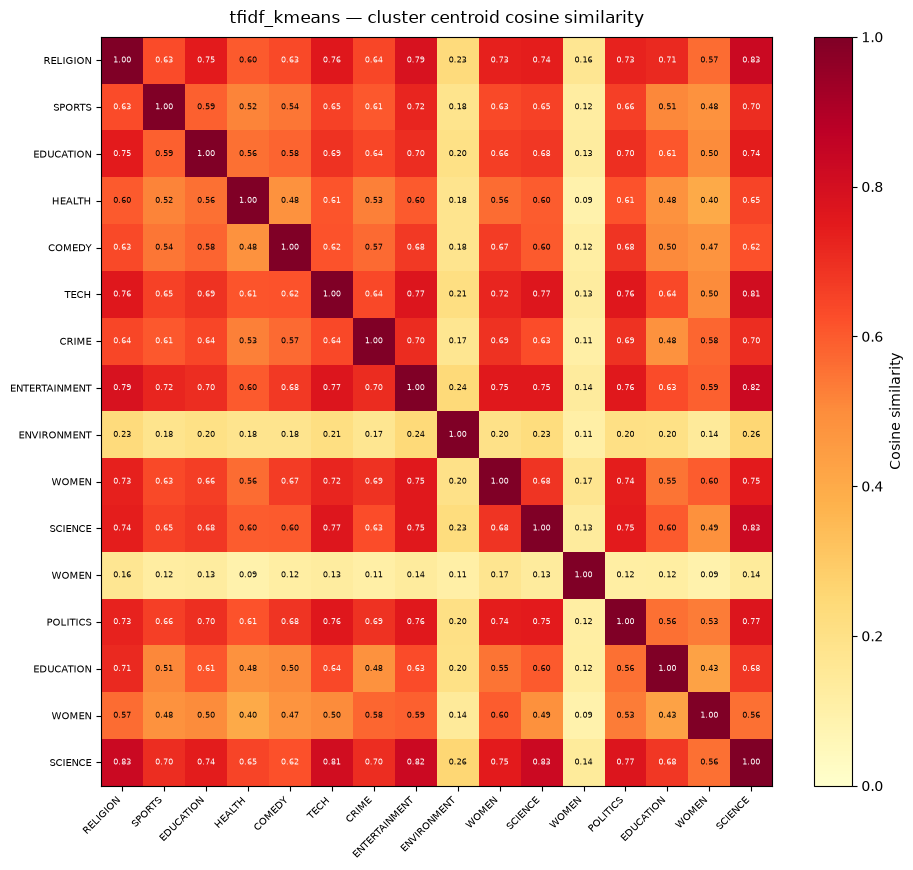

Saved: cluster_sim_heatmap_tfidf_kmeans.png


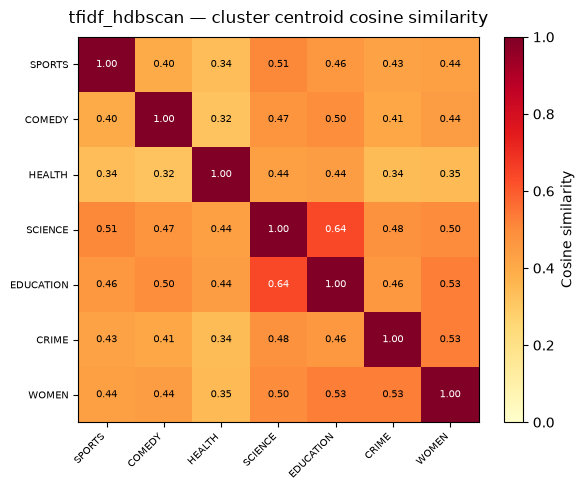

Saved: cluster_sim_heatmap_tfidf_hdbscan.png


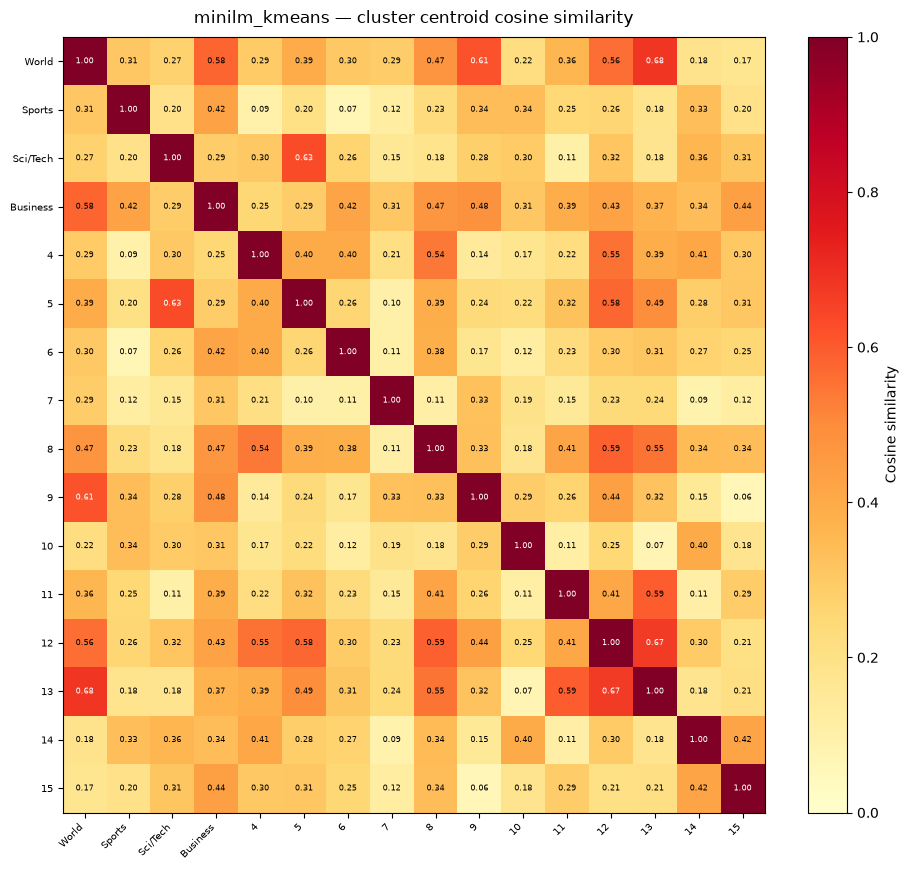

Saved: cluster_sim_heatmap_minilm_kmeans.png


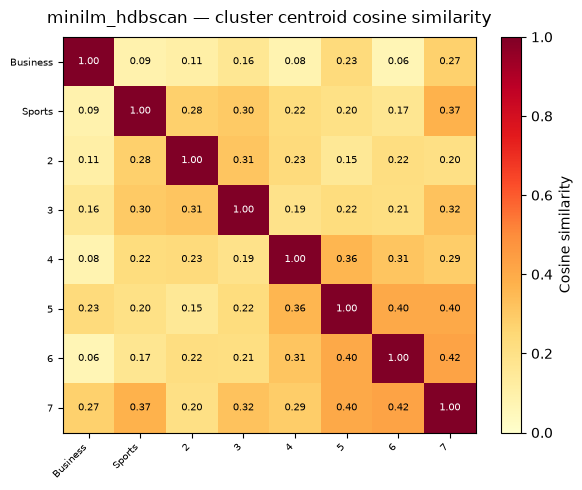

Saved: cluster_sim_heatmap_minilm_hdbscan.png


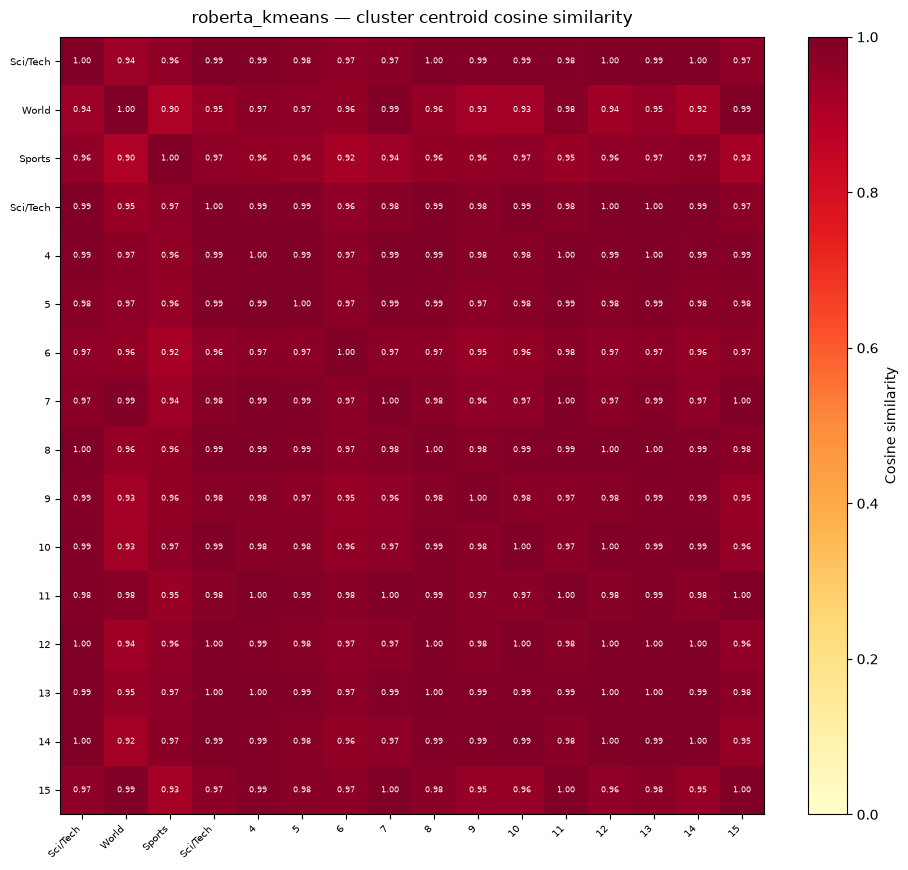

Saved: cluster_sim_heatmap_roberta_kmeans.png


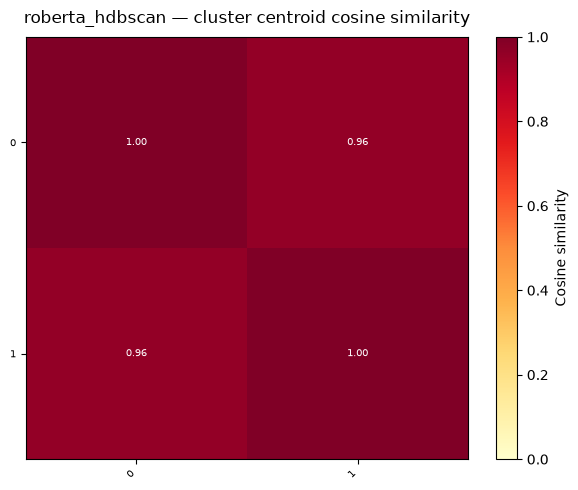

Saved: cluster_sim_heatmap_roberta_hdbscan.png


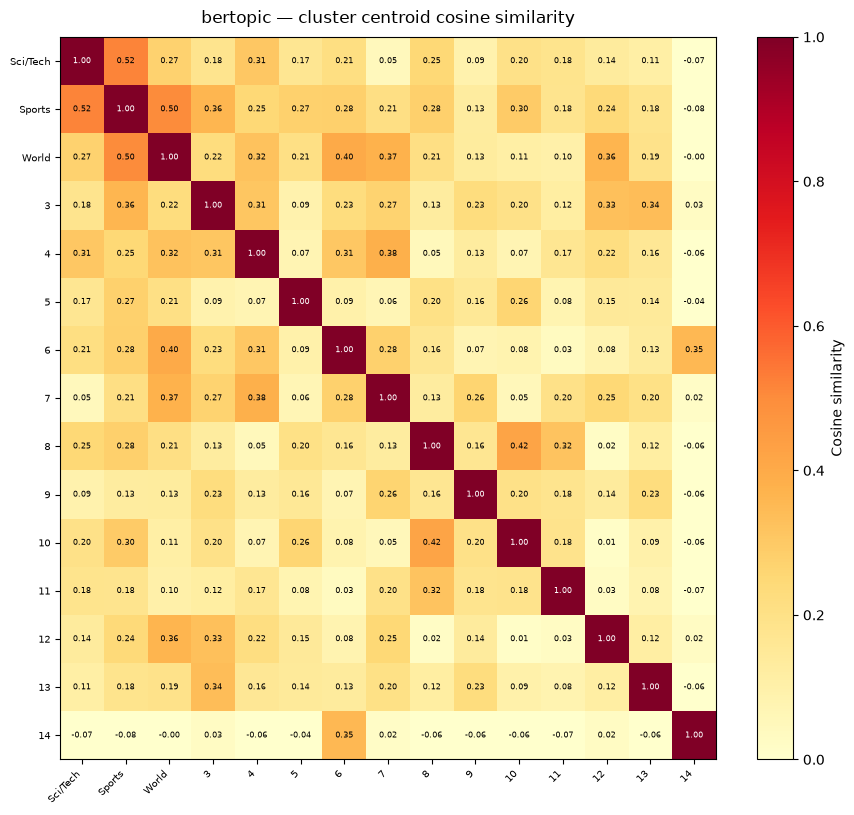

Saved: cluster_sim_heatmap_bertopic.png


In [8]:
for method_name, (cdf, inter_mat, cids) in all_stats.items():
    if cdf.empty or len(cids) < 2:
        print(f"{method_name}: too few clusters to plot heatmap — skipping")
        continue

    cname_map = cluster_name_map.get(method_name, {})
    tick_labels = [cname_map.get(c, str(c)) for c in cids]
    n = len(cids)

    fig, ax = plt.subplots(figsize=(max(6, n * 0.6), max(5, n * 0.55)))
    im = ax.imshow(inter_mat, vmin=0, vmax=1, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax, label="Cosine similarity")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(tick_labels, fontsize=7)

    # Annotate cells with similarity values
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{inter_mat[i, j]:.2f}",
                    ha="center", va="center",
                    fontsize=6 if n > 10 else 7,
                    color="white" if inter_mat[i, j] > 0.6 else "black")

    ax.set_title(f"{method_name} — cluster centroid cosine similarity", pad=10)
    plt.tight_layout()
    out_path = config.RESULTS_DIR / f"cluster_sim_heatmap_{method_name}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.name}")

## Cross-method bar chart

Intra-cluster (tighter = better) vs. inter-cluster (lower = more separated)
mean cosine similarity side-by-side. A high separation ratio (intra / inter)
means clusters are internally cohesive and mutually distinct.

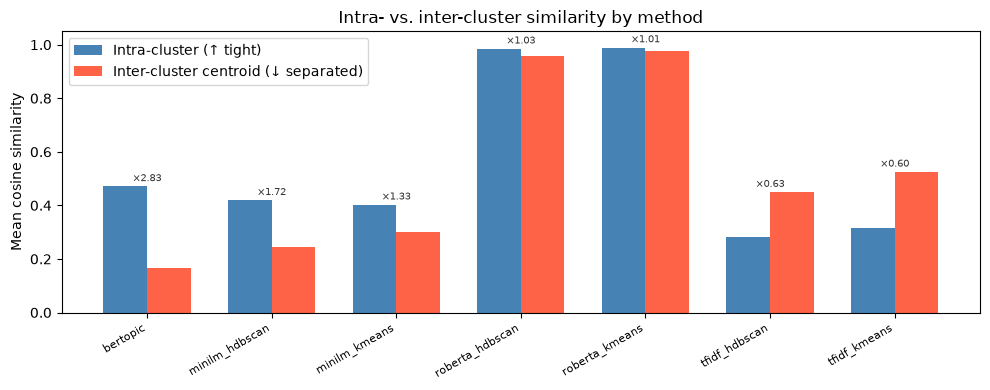

Saved: cluster_similarity_comparison.png


In [9]:
plot_df = summary_df[summary_df["mean_intra_sim"].notna()].copy()
plot_df = plot_df.set_index("method")

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width / 2, plot_df["mean_intra_sim"], width,
       label="Intra-cluster (↑ tight)", color="steelblue")
ax.bar(x + width / 2, plot_df["mean_inter_sim"], width,
       label="Inter-cluster centroid (↓ separated)", color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Mean cosine similarity")
ax.set_title("Intra- vs. inter-cluster similarity by method")
ax.set_ylim(0, 1.05)
ax.legend()

# Annotate separation ratio above each pair
for i, (_, row) in enumerate(plot_df.iterrows()):
    if not np.isnan(row["separation_ratio"]):
        ax.text(i, max(row["mean_intra_sim"], row["mean_inter_sim"]) + 0.02,
                f"×{row['separation_ratio']:.2f}",
                ha="center", fontsize=7, color="#333")

plt.tight_layout()
out_path = config.RESULTS_DIR / "cluster_similarity_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path.name}")